# NOTEBOOK NAME
Created by: Thomas Durand-Texte, 2023

# Import des packages et données
## import des packages

In [4]:
import os

import pandas as pd
import numpy as np
# import dask as dd
pd.set_option("display.max_columns", 200)

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

import nltk
import re
from string import punctuation

miss rate or false negative rate (FNR)
FNR = FN/P = FN / (FN+TP) = 1 − TPR = 1 - recall

$$ {\displaystyle \mathrm {FNR} ={\frac {\mathrm {FN} }{\mathrm {P} }}={\frac {\mathrm {FN} }{\mathrm {FN} +\mathrm {TP} }}=1-\mathrm {TPR} } $$


condition positive (P)
the number of real positive cases in the data

condition negative (N)
the number of real negative cases in the data

true positive (TP)
A test result that correctly indicates the presence of a condition or characteristic

true negative (TN)
A test result that correctly indicates the absence of a condition or characteristic

false positive (FP)
A test result which wrongly indicates that a particular condition or attribute is present

false negative (FN)
A test result which wrongly indicates that a particular condition or attribute is absent
sensitivity, recall, hit rate, or true positive rate (TPR)

$$
{\displaystyle \mathrm {TPR} ={\frac {\mathrm {TP} }{\mathrm {P} }}={\frac {\mathrm {TP} }{\mathrm {TP} +\mathrm {FN} }}=1-\mathrm {FNR} }

$$
specificity, selectivity or true negative rate (TNR)

$$
{\displaystyle \mathrm {TNR} ={\frac {\mathrm {TN} }{\mathrm {N} }}={\frac {\mathrm {TN} }{\mathrm {TN} +\mathrm {FP} }}=1-\mathrm {FPR} }
$$

precision or positive predictive value (PPV)

$$
{\displaystyle \mathrm {PPV} ={\frac {\mathrm {TP} }{\mathrm {TP} +\mathrm {FP} }}=1-\mathrm {FDR} }
$$

negative predictive value (NPV)
$$
{\displaystyle \mathrm {NPV} ={\frac {\mathrm {TN} }{\mathrm {TN} +\mathrm {FN} }}=1-\mathrm {FOR} }
$$

miss rate or false negative rate (FNR)
$${\displaystyle \mathrm {FNR} ={\frac {\mathrm {FN} }{\mathrm {P} }}={\frac {\mathrm {FN} }{\mathrm {FN} +\mathrm {TP} }}=1-\mathrm {TPR} }
$$

fall-out or false positive rate (FPR)
$$
{\displaystyle \mathrm {FPR} ={\frac {\mathrm {FP} }{\mathrm {N} }}={\frac {\mathrm {FP} }{\mathrm {FP} +\mathrm {TN} }}=1-\mathrm {TNR} }
$$

false discovery rate (FDR)
$$
{\displaystyle \mathrm {FDR} ={\frac {\mathrm {FP} }{\mathrm {FP} +\mathrm {TP} }}=1-\mathrm {PPV} }
$$

false omission rate (FOR)
$${\displaystyle \mathrm {FOR} ={\frac {\mathrm {FN} }{\mathrm {FN} +\mathrm {TN} }}=1-\mathrm {NPV} }
$$

Positive likelihood ratio (LR+)
$${\displaystyle \mathrm {LR+} ={\frac {\mathrm {TPR} }{\mathrm {FPR} }}}
$$

Negative likelihood ratio (LR-)
$${\displaystyle \mathrm {LR-} ={\frac {\mathrm {FNR} }{\mathrm {TNR} }}}
$$

prevalence threshold (PT)
$${\displaystyle \mathrm {PT} ={\frac {\sqrt {\mathrm {FPR} }}{{\sqrt {\mathrm {TPR} }}+{\sqrt {\mathrm {FPR} }}}}}
$$

threat score (TS) or critical success index (CSI)
$${\displaystyle \mathrm {TS} ={\frac {\mathrm {TP} }{\mathrm {TP} +\mathrm {FN} +\mathrm {FP} }}}
$$

Prevalence
$${\displaystyle {\frac {\mathrm {P} }{\mathrm {P} +\mathrm {N} }}}
$$

accuracy (ACC)
$${\displaystyle \mathrm {ACC} ={\frac {\mathrm {TP} +\mathrm {TN} }{\mathrm {P} +\mathrm {N} }}={\frac {\mathrm {TP} +\mathrm {TN} }{\mathrm {TP} +\mathrm {TN} +\mathrm {FP} +\mathrm {FN} }}}
$$

balanced accuracy (BA)
$${\displaystyle \mathrm {BA} ={\frac {TPR+TNR}{2}}}
$$

F1 score is the harmonic mean of precision and sensitivity: 
$${\displaystyle \mathrm {F} _{1}=2\times {\frac {\mathrm {PPV} \times \mathrm {TPR} }{\mathrm {PPV} +\mathrm {TPR} }}={\frac {2\mathrm {TP} }{2\mathrm {TP} +\mathrm {FP} +\mathrm {FN} }}}
$$

phi coefficient (φ or rφ) or Matthews correlation coefficient (MCC)
$${\displaystyle \mathrm {MCC} ={\frac {\mathrm {TP} \times \mathrm {TN} -\mathrm {FP} \times \mathrm {FN} }{\sqrt {(\mathrm {TP} +\mathrm {FP} )(\mathrm {TP} +\mathrm {FN} )(\mathrm {TN} +\mathrm {FP} )(\mathrm {TN} +\mathrm {FN} )}}}}
$$

Fowlkes–Mallows index (FM)
$${\displaystyle \mathrm {FM} ={\sqrt {{\frac {TP}{TP+FP}}\times {\frac {TP}{TP+FN}}}}={\sqrt {PPV\times TPR}}}
$$

informedness or bookmaker informedness (BM)
$${\displaystyle \mathrm {BM} =\mathrm {TPR} +\mathrm {TNR} -1}
$$

markedness (MK) or deltaP (Δp)
$${\displaystyle \mathrm {MK} =\mathrm {PPV} +\mathrm {NPV} -1}
$$

Diagnostic odds ratio (DOR)
$${\displaystyle \mathrm {DOR} ={\frac {\mathrm {LR+} }{\mathrm {LR-} }}}
$$

In [3]:
import gensim.downloader
glove_vectors = gensim.downloader.load('glove-wiki-gigaword-300')

[==================================================] 100.0% 376.1/376.1MB downloaded


In [12]:
glove_vectors.save('Word2Vect.model')

In [13]:
w2v_words = glove_vectors.index_to_key
print("Vocabulary size: %i" % len(w2v_words))
print("Word2Vec trained")

Vocabulary size: 400000
Word2Vec trained


In [ ]:
from gensim.models import KeyedVectors
glove_vectors = KeyedVectors.load('Word2Vect.model')

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


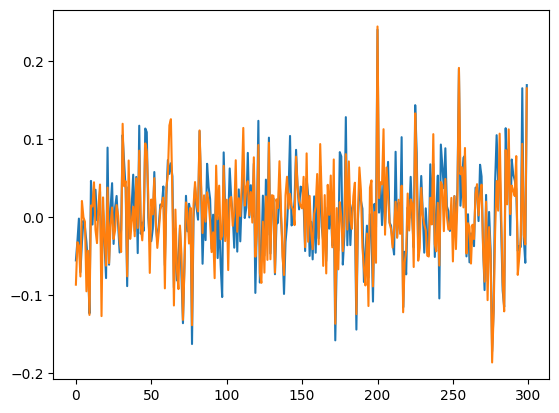

In [38]:
w1 = glove_vectors.get_mean_vector(['daughter'])
w1_2 = glove_vectors.get_mean_vector(['daughter', 'daughter'])
w1_3 = glove_vectors.get_mean_vector(['daughter daughter '])

print(w1 - w1_2)

w2 = glove_vectors.get_mean_vector(['girl'])
w3 = glove_vectors.get_mean_vector(['son'])
w4 = glove_vectors.get_mean_vector(['boy'])

import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.plot( w3-w4+w2)
ax.plot( w1 )
# ((body-torso) - head)

In [1]:
import tensorflow as tf
import tensorflow_hub as hub

module_url = "https://tfhub.dev/google/universal-sentence-encoder/4"
model = hub.load(module_url)
print ("module %s loaded" % module_url)
def embed(input):
  return model(input)

2023-05-07 16:12:30.428045: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-05-07 16:12:30.431223: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-05-07 16:12:30.477054: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-05-07 16:12:30.477868: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-05-07 16:12:31.410423: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Co

module https://tfhub.dev/google/universal-sentence-encoder/4 loaded


In [5]:
word = "Elephant"
sentence = "I am a sentence for which I would like to get its embedding."
paragraph = (
    "Universal Sentence Encoder embeddings also support short paragraphs. "
    "There is no hard limit on how long the paragraph is. Roughly, the longer "
    "the more 'diluted' the embedding will be.")
messages = [word, sentence, paragraph]

# Reduce logging output.
# logging.set_verbosity(logging.ERROR)

message_embeddings = embed(messages)

for i, message_embedding in enumerate(np.array(message_embeddings).tolist()):
  print("Message: {}".format(messages[i]))
  print("Embedding size: {}".format(len(message_embedding)))
  message_embedding_snippet = ", ".join(
      (str(x) for x in message_embedding[:3]))
  print("Embedding: [{}, ...]\n".format(message_embedding_snippet))

Message: Elephant
Embedding size: 512
Embedding: [0.00834445096552372, 0.0004808200756087899, 0.06595247238874435, ...]

Message: I am a sentence for which I would like to get its embedding.
Embedding size: 512
Embedding: [0.0508086271584034, -0.016524292528629303, 0.015737809240818024, ...]

Message: Universal Sentence Encoder embeddings also support short paragraphs. There is no hard limit on how long the paragraph is. Roughly, the longer the more 'diluted' the embedding will be.
Embedding size: 512
Embedding: [-0.028332697227597237, -0.05586221069097519, -0.012941492721438408, ...]



In [7]:
import pickle
with open('test_USE.pickle', 'wb') as file:
    pickle.dump(model, file)

AttributeError: Can't pickle local object 'Loader._recreate_base_user_object.<locals>._UserObject'

---

In [2]:
corpus = pd.Series([['a', 'b', 'c'], ['a', 'e', 'f'], ['a', 'b', 'g']])
display(corpus)
vectorizer = TfidfVectorizer()
vectorizer.fit(corpus)

0    [a, b, c]
1    [a, e, f]
2    [a, b, g]
dtype: object

AttributeError: 'list' object has no attribute 'lower'

In [22]:
SW = set(tuple(nltk.corpus.stopwords.words('french')))

def tokenize(text, tags):
    tokenizer = nltk.tokenize.ToktokTokenizer()
    # tokenizer = nltk.tokenize.word_tokenize
    # tokenizer = nltk.RegexpTokenizer(r'\w+').tokenize
    out = []
    regex = re.compile('[' + re.escape(punctuation) + ']')
    for word in tokenizer.tokenize(text):
        if (word in SW) or (word in punctuation):
            continue
        if word in tags:
            out.append(word)
            continue
        out.append(regex.sub('', word))
    return out

In [20]:
text = "c# test. Bonjour, je suis un texte d'exemple pour le cours d'Openclassrooms. Soyez attentifs à ce cours !"

# tokenizer = nltk.RegexpTokenizer(r'\w+')
tokenizer = nltk.ToktokTokenizer()
tokens = tokenizer.tokenize(text)

regex = re.compile('[' + re.escape(punctuation) + ']')
print([(w, regex.sub('', w)) for w in tokens])
print(','.join([regex.sub('', w) for w in tokens]))

[('c#', 'c'), ('test.', 'test'), ('Bonjour', 'Bonjour'), (',', ''), ('je', 'je'), ('suis', 'suis'), ('un', 'un'), ('texte', 'texte'), ('d', 'd'), ("'", ''), ('exemple', 'exemple'), ('pour', 'pour'), ('le', 'le'), ('cours', 'cours'), ('d', 'd'), ("'", ''), ('Openclassrooms.', 'Openclassrooms'), ('Soyez', 'Soyez'), ('attentifs', 'attentifs'), ('à', 'à'), ('ce', 'ce'), ('cours', 'cours'), ('!', '')]
c,test,Bonjour,,je,suis,un,texte,d,,exemple,pour,le,cours,d,,Openclassrooms,Soyez,attentifs,à,ce,cours,


In [23]:
tokenize(text, ['c#'])

['c#',
 'test',
 'Bonjour',
 'texte',
 'exemple',
 'cours',
 'Openclassrooms',
 'Soyez',
 'attentifs',
 'cours']

In [5]:
sw = set(tuple(nltk.corpus.stopwords.words('english')))
'.' in sw

False